# Comparision of assemblied isoforms

This notebook compare the assemblied isoforms and known isoforms.

In [15]:
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)

runs = [
    "20220719_K562_1", 
    "20220719_K562_2", 
    "20220719_K562_3", 
    "20220719_K562_4", 
    "20220729_K562_1", 
    "20220729_K562_2",
]
d1 = info[info["Run"].isin(runs)]
d1 = d1[d1["UMIs"] >= 5000] 
print("K562 cells:", len(d1))

runs = [
    "20220818_mESC_1", 
    "20220818_mESC_2", 
    "20220818_mESC_3", 
]
d2 = info[info["Run"].isin(runs)]
d2 = d2[d2["UMIs"] >= 5000] 
print("mESC cells:", len(d2))

K562 cells: 426
mESC cells: 213


In [18]:
def stat_sqanti3_category(infile, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
    names = [
        'full-splice_match', 
        'incomplete-splice_match', 
        'novel_in_catalog', 
        'novel_not_in_catalog',
        'antisense', 
        'fusion', 
        'genic', 
        'intergenic'
    ]      
    rows = []
    for path in infiles:
        tmp = pd.read_csv(path, sep="\t")
        counter = Counter(tmp["structural_category"])
        rows.append([counter[name] for name in names])
    m = pd.DataFrame(rows)
    m.columns = ["FSM", "ISM", "NIC", "NNC", "AntiSense", "Fusion", "Genic", "Intergenic"]
    m.to_csv(outfile, index=False)

for name, d in zip(["K562", "mESC"], [d1, d2]):
    infiles = ["../../../1_NanoNASCseq/results/6_assembly/2_sqanti3/%s/%s/%s_classification.filtered_lite_classification.txt" % (cell.split(".")[0], cell, cell) for cell in d.index]
    outfile = "results/sqanti3_category.stats.%s.csv" % name
    stat_sqanti3_category(infiles, outfile)

results/sqanti3_category.stats.K562.csv exists!


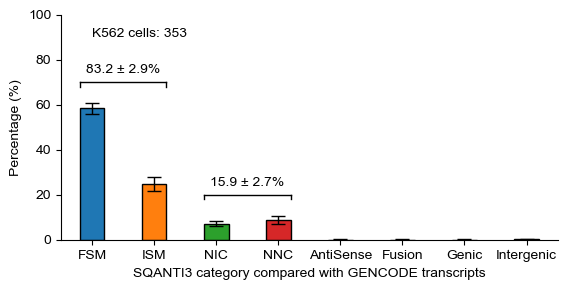

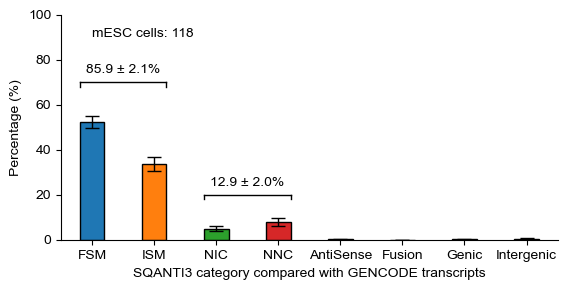

In [26]:
for name in ["K562", "mESC"]:
    m = pd.read_csv("results/sqanti3_category.stats.%s.csv" % name)
    m1 = m[m.sum(axis=1) > 2000]
    m2 = m1.divide(m1.sum(axis=1), axis=0) * 100
    vs1 = m2["FSM"] + m2["ISM"]
    vs2 = m2["NIC"] + m2["NNC"]
    
    ys = m2.mean(axis=0)
    yerr = m2.std(axis=0)
    xs = np.arange(len(ys))
    
    colors = ["C0", "C1", "C2", "C3", "C7", "C7", "C7", "C7"]
    plt.figure(figsize=(5.8, 3))
    # plt.title("SQANTI3 category compared with GENCODE transcripts")
    
    plt.bar(xs, ys, yerr=yerr, width=0.4, color=colors, edgecolor="black", error_kw={"capsize": 5, "lw": 1})
    plt.text(0, 90, "%s cells: %d" % (name, len(m2)))
    plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
    plt.ylim(0, 100)
    
    x1, x2 = 0 - 0.2, 1 + 0.2
    y = 70
    plt.plot([x1, x2], [y, y], lw=1, color="black")
    plt.plot([x1, x1], [y - 2, y], lw=1, color="black")
    plt.plot([x2, x2], [y - 2, y], lw=1, color="black")
    plt.text((x1 + x2) / 2, y + 4, "%.1f ± %.1f%%" % (np.mean(vs1), np.std(vs1)), ha="center")
    
    x1, x2 = 2 - 0.2, 3 + 0.2
    y = 20
    plt.plot([x1, x2], [y, y], lw=1, color="black")
    plt.plot([x1, x1], [y - 2, y], lw=1, color="black")
    plt.plot([x2, x2], [y - 2, y], lw=1, color="black")
    plt.text((x1 + x2) / 2, y + 4, "%.1f ± %.1f%%" % (np.mean(vs2), np.std(vs2)), ha="center")
    
    plt.xticks(xs, m2.columns, rotation=0)
    plt.xlabel("SQANTI3 category compared with GENCODE transcripts")
    plt.ylabel("Percentage (%)")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    
    plt.tight_layout()
    plt.savefig("figures/sqanti3_category.bar.%s.pdf" % name)
    plt.show()
    plt.close()